# **LightGBM & Multi-Class Classification Project (>10 Target Classes)**

In this project, we implement and evaluate **Multi-Class Machine Learning Models** to predict target categories with high cardinality (>10 target classes). Specifically, we predict `product_id` across 100 distinct organic food product classes using feature engineering indicators.

### **Key Highlights**
- Target Variable: `product_id` (**100 target classes**)
- Comparative Multi-Class Algorithms: **LightGBM Multiclass Classifier**, **XGBoost Multiclass Classifier**, and **Random Forest Classifier**
- Key Evaluation Metrics: Top-1 Accuracy, Top-3 Accuracy, Top-5 Accuracy, Weighted F1-Score, and Multiclass Log Loss.

## **1. Load Libraries & Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, top_k_accuracy_score, f1_score,
    precision_score, recall_score, log_loss, classification_report, confusion_matrix
)

import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier

print("Libraries loaded successfully!")

Libraries loaded successfully!


## **2. Load Dataset & Preview Target Distribution**

In [3]:
# SHAP-selected 20 optimal features
selected_features = [
    'min_pp', 'p90_pp', 'p95_pad', 'p25_pp', 'p95_pp', 'max_pp',
    'min_pad', 'p75_pp', 'max_pad', 'p90_pad', 'avg_pp', 'p50_pp',
    'p25_pad', 'p50_pad', 'avg_pad', 'p75_pad', 'p90_pd', 'total_pad',
    'max_pd', 'p95_pd'
]
target_col = 'product_id'

# Load dataset
cols_to_use = selected_features + [target_col]
df = pd.read_csv('Final_Feature_code.csv', usecols=cols_to_use)
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1410027, 21)


,total_pad,avg_pad,min_pad,max_pad,max_pd,avg_pp,min_pp,max_pp,p25_pad,p50_pad,...,p90_pad,p95_pad,p90_pd,p95_pd,p25_pp,p50_pp,p75_pp,p90_pp,p95_pp,product_id
0,34.93,34.930,34.93,34.93,10,38.8096,38.8096,38.8096,34.9300,34.930,...,34.930,34.9300,10.0,10.00,38.8096,38.8096,38.8096,38.80960,38.80960,421
1,55.17,55.170,55.17,55.17,19,68.1097,68.1097,68.1097,55.1700,55.170,...,55.170,55.1700,19.0,19.00,68.1097,68.1097,68.1097,68.10970,68.10970,266
2,47.00,47.000,47.00,47.00,17,56.6209,56.6209,56.6209,47.0000,47.000,...,47.000,47.0000,17.0,17.00,56.6209,56.6209,56.6209,56.62090,56.62090,233
3,19.49,19.490,19.49,19.49,9,21.4230,21.4230,21.4230,19.4900,19.490,...,19.490,19.4900,9.0,9.00,21.4230,21.4230,21.4230,21.42300,21.42300,139
4,62.91,31.455,27.60,35.31,20,39.0507,34.5061,43.5953,29.5275,31.455,...,34.539,34.9245,19.9,19.95,36.7784,39.0507,41.3230,42.68638,43.14084,235


In [4]:
# Check target distribution (>10 classes check)
num_unique_classes = df[target_col].nunique()
print(f"Target Column: {target_col}")
print(f"Total Unique Classes: {num_unique_classes}")
print("\nTop 10 Most Frequent Product Classes:")
print(df[target_col].value_counts().head(10))

Target Column: product_id
Total Unique Classes: 100

Top 10 Most Frequent Product Classes:
product_id
103    14342
153    14290
161    14289
369    14281
425    14275
36     14261
266    14238
179    14221
184    14217
67     14208
Name: count, dtype: int64


## **3. Data Preprocessing & Target Encoding**

In [5]:
# Subsample data for efficient model training if dataset is very large
if len(df) > 150000:
    df_sample, _ = train_test_split(
        df, train_size=150000, stratify=df[target_col], random_state=42
    )
else:
    df_sample = df.copy()

X = df_sample[selected_features]
y_raw = df_sample[target_col]

# Encode product_id targets from 0 to num_classes-1
le = LabelEncoder()
y = le.fit_transform(y_raw)
num_classes = len(le.classes_)

# Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print(f"Encoded {num_classes} classes successfully (0 to {num_classes-1}).")

Encoded 100 classes successfully (0 to 99).


## **4. Train / Test Split**

In [6]:
# Split dataset into 80% train and 20% test with stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape:  {X_test.shape}")

Training set shape: (120000, 20)
Testing set shape:  (30000, 20)


## **5. Multi-Class Model Training & Comparison**

We train three top multi-class algorithms best suited for >10 target classes:
1. **LightGBM Classifier** (`objective='multiclass'`, `num_class=100`)
2. **XGBoost Classifier** (`objective='multi:softprob'`, `num_class=100`)
3. **Random Forest Classifier** (`RandomForestClassifier`)

In [7]:
# 5.1 LightGBM Multiclass Model
print("Training LightGBM Multiclass Model...")
t0 = time.time()
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=num_classes,
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbosity=-1,
    n_jobs=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_time = round(time.time() - t0, 2)
print(f"LightGBM Training Completed in {lgbm_time}s")

Training LightGBM Multiclass Model...
LightGBM Training Completed in 52.69s


In [8]:
# 5.2 XGBoost Multiclass Model
print("Training XGBoost Multiclass Model...")
t0 = time.time()
xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=num_classes,
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss'
)
xgb_model.fit(X_train, y_train)
xgb_time = round(time.time() - t0, 2)
print(f"XGBoost Training Completed in {xgb_time}s")

Training XGBoost Multiclass Model...
XGBoost Training Completed in 56.68s


In [9]:
# 5.3 Random Forest Multiclass Model
print("Training Random Forest Multiclass Model...")
t0 = time.time()
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_time = round(time.time() - t0, 2)
print(f"Random Forest Training Completed in {rf_time}s")

Training Random Forest Multiclass Model...
Random Forest Training Completed in 5.94s


## **6. Multi-Class Evaluation Metrics & Model Comparison**

In [10]:
models = {'LightGBM': lgbm_model, 'XGBoost': xgb_model, 'RandomForest': rf_model}
times = {'LightGBM': lgbm_time, 'XGBoost': xgb_time, 'RandomForest': rf_time}
results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    top3_acc = top_k_accuracy_score(y_test, y_proba, k=3)
    top5_acc = top_k_accuracy_score(y_test, y_proba, k=5)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_proba)
    
    results.append({
        'Model': name,
        'Top-1 Accuracy': round(acc, 4),
        'Top-3 Accuracy': round(top3_acc, 4),
        'Top-5 Accuracy': round(top5_acc, 4),
        'Weighted F1': round(f1_w, 4),
        'Log Loss': round(loss, 4),
        'Train Time (s)': times[name]
    })

comparison_df = pd.DataFrame(results).sort_values('Top-1 Accuracy', ascending=False)
comparison_df

,Model,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,Weighted F1,Log Loss,Train Time (s)
0,LightGBM,0.9720,0.9991,0.9993,0.9720,0.1119,52.69
1,XGBoost,0.9707,0.9990,0.9993,0.9707,0.0708,56.68
2,RandomForest,0.9650,0.9791,0.9833,0.9652,1.1058,5.94


## **7. Classification Report & Confusion Matrix**

In [11]:
# Detailed Classification Report for Best Model (LightGBM)
y_pred_lgb = lgbm_model.predict(X_test)
print("=== LightGBM Classification Report (Top 15 Classes Summary) ===")
report_dict = classification_report(y_test, y_pred_lgb, output_dict=True, zero_division=0)
pd.DataFrame(report_dict).T.head(15)

=== LightGBM Classification Report (Top 15 Classes Summary) ===


,precision,recall,f1-score,support
0,0.970297,0.980000,0.975124,300.0
1,0.979866,0.970100,0.974958,301.0
2,0.973333,0.976589,0.974958,299.0
3,0.944625,0.973154,0.958678,298.0
4,0.976898,0.989967,0.983389,299.0
5,0.967320,0.976898,0.972085,303.0
6,0.993174,0.966777,0.979798,301.0
7,0.976744,0.976744,0.976744,301.0
8,0.969697,0.960000,0.964824,300.0
9,0.963211,0.966443,0.964824,298.0


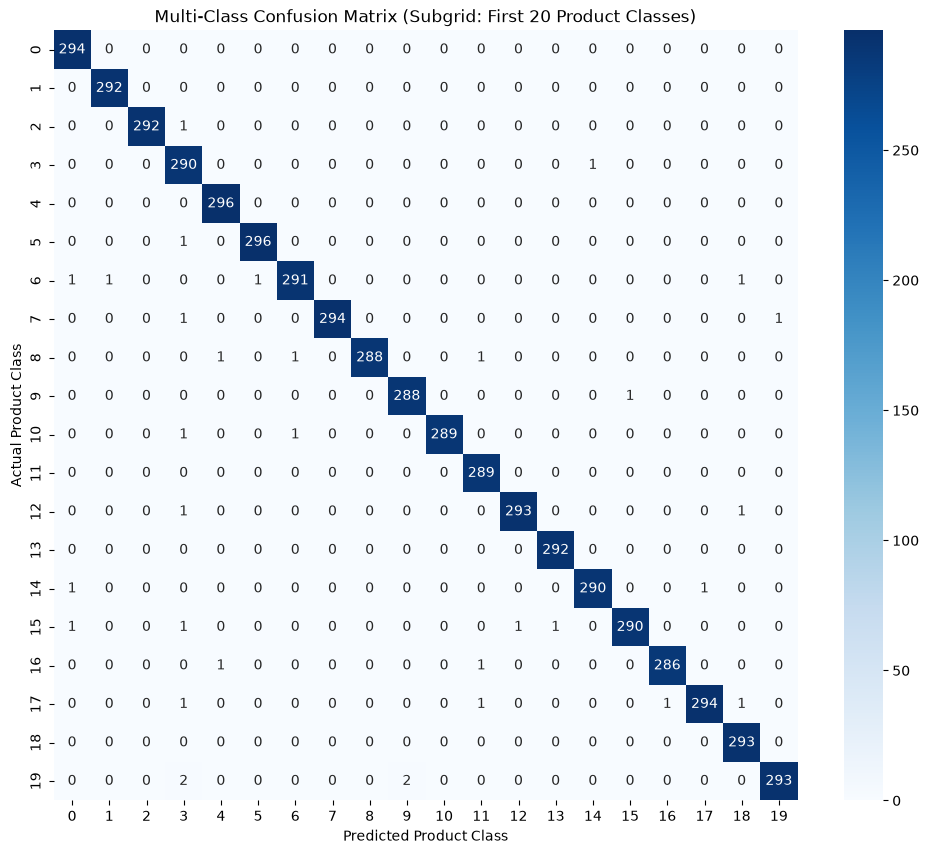

In [12]:
# Visualize Aggregated Confusion Matrix Heatmap (First 20 Classes)
cm = confusion_matrix(y_test, y_pred_lgb)
plt.figure(figsize=(12, 10))
sns.heatmap(cm[:20, :20], annot=True, fmt='d', cmap='Blues')
plt.title('Multi-Class Confusion Matrix (Subgrid: First 20 Product Classes)')
plt.xlabel('Predicted Product Class')
plt.ylabel('Actual Product Class')
plt.show()

## **8. Save Trained Models**

In [13]:
# Save trained models to disk
with open('lgbm_multiclass_model.pkl', 'wb') as f:
    pickle.dump(lgbm_model, f)

with open('xgb_multiclass_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('rf_multiclass_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("All multi-class models saved successfully!")

All multi-class models saved successfully!
